# Agent Frameworks - Agno Additional Lab
The code on this lab proposes a multi-step orchestration pipeline powered by a local LLM (Ollama running Qwen 2.5). The goal is to ingest an initial product prompt, dynamically generate a marketing tagline, translate it into Spanish, pause execution for a human confirmation step, and conditionally write the final output to the local file system using the Model Context Protocol (MCP).

## A graph-based **workflow engine** with human-in-the-loop approval
Agno's design philosophy is different from Strands/MAF here — `MCPTools` is meant to be attached to an **Agent's** `tools` list and invoked by the LLM's own tool-calling loop, not called directly via something like `call_tool_sync()`/`call_tool()`. There's no publicly documented "raw call" method on `MCPTools` the way Strands and MAF expose one. So the idiomatic Agno version routes the file-save step through a small dedicated agent that owns the MCP tool, rather than calling it imperatively.


**Key differences from Strands/MAF you designed around earlier:**
| Concern | Strands | MAF | Agno | Pydantic AI (`pydantic_graph`) |
|---|---|---|---|---|
| Graph structure | `GraphBuilder.add_edge(condition=...)` pairs, manual `should_skip` inverse edge | `Executor`/`WorkflowContext`, manual edge wiring | `Condition(steps=[...])` block — steps outside it always run, no inverse-condition edge needed | `g.edge_from(...).to(...)` pairs, with `g.decision().branch(g.match(...).to(...))` for conditional routing — closer to Strands' explicit-edge style than Agno's implicit fallthrough |
| Shared state | Plain dict via `invocation_state` | `ctx.get_state`/`ctx.send_message` | `session_state: dict` param on Step functions, merged back automatically | Typed dataclass (`WorkflowState`), mutated directly as `ctx.state.saved_text = ...` inside any `@g.step` function — no merge-back subtlety since it's the same object throughout the run |
| Custom function nodes | Needed a `FunctionNode(MultiAgentBase)` wrapper class | Native `Executor` subclass + `@handler` | Native — plain function as `executor=` | Native — every node is just an `async def` decorated with `@g.step`, typed via `StepContext[State, Deps, InputType]` |
| MCP invocation | `call_tool_sync(...)` — direct client call | `call_tool(...)` — direct client call | No direct call API; MCP tools attach to an `Agent`, invoked via its own tool-calling loop | `MCPToolset(...).direct_call_tool(...)` — a **direct, deterministic call**, same spirit as Strands/MAF, not routed through an agent's reasoning like Agno |
| Visualization | No built-in viz (hand-rolled from `builder.nodes`/`.edges`) | No built-in viz | No built-in viz (hand-rolled from `workflow.steps`) | **Built-in**, dual API — classic `Graph.mermaid_code(start_node=...)` for `BaseNode`-style graphs, or `graph.render(title=..., direction=...)` for the beta `GraphBuilder` pattern (what you're using) — no introspection needed |

One thing to watch when you run this: since `save_file` now goes through an LLM tool-call (`qwen2.5:7b` deciding to invoke `write_file`) rather than a deterministic direct call, it's less predictable than the others approach — the model could paraphrase content, add commentary, or simply not call the tool (the same "model didn't call the tool" failure mode you saw with `save_text` earlier in the graph history). If you want deterministic writes rather than depending on the model choosing to call the MCP tool correctly, you can skip the agent wrapper entirely and just do the manual `file_path.write_text(...)` write as the primary path — Agno doesn't penalize you for not using MCP inside a `Step`, since plain functions are first-class citizens here, unlike Strands' workaround-required approach.

In [5]:
import asyncio
from pathlib import Path
from dotenv import load_dotenv
from agno.agent import Agent
from agno.models.openai.like import OpenAILike  # same OpenAI-compatible /v1 route that fixed your Ollama 404 in Strands
from agno.tools.mcp import MCPTools
from agno.workflow import Condition, Step, Workflow
from agno.workflow.step import StepInput, StepOutput
from agno.run import RunContext

# -------------------------------------------------------------------
# Workspace definition
workspace = Path("workspace").resolve()
workspace.mkdir(exist_ok=True)

# -------------------------------------------------------------------
# to Ollama's OpenAI-compatible endpoint rather than its native API,
# since that's what resolved the 404 earlier)
ollama_model = OpenAILike(
    id="qwen2.5:7b",
    api_key="ollama",
    base_url="http://localhost:11434/v1",
    temperature=0.1,
    seed=42
)

# -------------------------------------------------------------------
# worker Agents definition
writer_agent = Agent(
    name="WriterAgent",
    model=ollama_model,
    instructions="You are a professional creative marketer. Write a concise, 1-sentence product tagline. Do not use quotation marks.",
)

translator_agent = Agent(
    name="TranslatorAgent",
    model=ollama_model,
    instructions="You are an expert translator. Translate the given text exactly into natural Spanish. Return only the final Spanish text.",
)

# -------------------------------------------------------------------
# Human-In-The-Loop step
def ask_human(step_input: StepInput, session_state: dict) -> StepOutput:
    """
    Agno custom function steps take (StepInput, RunContext) and return
    StepOutput - this replaces Strands' FunctionNode and MAF's Executor.
    """
    text = step_input.previous_step_content or ""
    print(f"\n🔍 [TRANSLATION PREVIEW]:\n{text}")

    session_state["saved_text"] = text

    answer = input("💾 Would you like to save this translation to a file? (y/n): ").strip().lower()
    print(f"🔍 DEBUG: received answer = {answer!r}")
    session_state["should_save"] = answer in ("y", "yes")
    print(f"🔍 DEBUG: should_save = {session_state['should_save']!r}")
    return StepOutput(content=text)


interrupter_step = Step(name="interrupter", executor=ask_human)

# -------------------------------------------------------------------
# File Saver Step
async def save_file(step_input: StepInput, session_state: dict) -> StepOutput:
    """
    Agno routes MCP through an Agent's tool-calling loop rather than a
    direct call_tool() API - so we spin up a small dedicated agent whose
    only job is writing the file via the filesystem MCP server.
    """
    text_to_save = session_state.get("saved_text", "")
    print("\n🔧 [WORKFLOW INTEROP] Handing file operation over to MCP Filesystem...")

    target_path = workspace / "agno_translate.txt"

    try:
        async with MCPTools(f"npx -y @modelcontextprotocol/server-filesystem {workspace}") as fs_tools:
            saver_agent = Agent(
                name="FileSaverAgent",
                model=ollama_model,
                tools=[fs_tools],
                instructions=(
                    "You save text to disk when asked. Use the write_file tool exactly once "
                    "with the exact absolute path given, then confirm."
                ),
            )
            # Use the absolute path so it matches the MCP server's allowed root exactly
            prompt = f"Write exactly this content to path '{target_path}':\n\n{text_to_save}"
            response = await saver_agent.arun(prompt)
            print(f"🔍 DEBUG: agent response = {response.content!r}")

        # Don't trust the agent's word - verify the file actually landed
        if target_path.exists() and target_path.read_text(encoding="utf-8").strip() == text_to_save.strip():
            print(f"✨ SUCCESS: MCP tool written to {target_path}")
        else:
            raise RuntimeError("MCP write could not be verified on disk")

    except Exception as e:
        print(f"⚠️ Direct MCP call failed or unverified ({e}). Falling back to manual write...")
        target_path.write_text(text_to_save, encoding="utf-8")
        print(f"✨ Fallback SUCCESS: File created at {target_path.resolve()}")

    return StepOutput(content=text_to_save)


saver_step = Step(name="saver", executor=save_file)

# -------------------------------------------------------------------
# Conditional Branch
def should_save(step_input: StepInput, session_state: dict) -> bool:
    """
    Agno's Condition primitive replaces Strands' add_edge(condition=...)
    pairs - no need for a separate "should_skip" edge, since steps
    outside the Condition always run regardless of branch taken.
    """
    result = session_state.get("should_save", False)
    print(f"🔍 DEBUG: Condition evaluator sees should_save = {result!r}")
    return result


save_condition = Condition(
    name="save_branch",
    evaluator=should_save,
    steps=[saver_step],
)

# -------------------------------------------------------------------
# FORMATTER STEP
def format_output(step_input: StepInput, session_state: dict) -> StepOutput:
    """always runs, whether or not saver ran"""
    text = session_state.get("saved_text", "")
    return StepOutput(content=f"*** BRAND OUTPUT ***\n{text.upper()}")


formatter_step = Step(name="formatter", executor=format_output)

# -------------------------------------------------------------------
# Build Workflow
translation_workflow = Workflow(
    name="Translation Workflow",
    steps=[
        Step(name="writer", agent=writer_agent),
        Step(name="translator", agent=translator_agent),
        interrupter_step,
        save_condition,
        formatter_step,
    ],
    session_state={"saved_text": "", "should_save": False},
)

# -------------------------------------------------------------------
# Workflow Execution
async def main():
    print("🎬 Starting Agno Translation Workflow...")
    result = await translation_workflow.arun(
        "A high-performance organic energy drink for programmers."
    )
    print("\n🏁 [WORKFLOW EXECUTION COMPLETE]")
    print(result.content)

await main()

🎬 Starting Agno Translation Workflow...


INFO Executing async step (non-streaming): writer

INFO Executing async step (non-streaming): translator

INFO Executing async step (non-streaming): interrupter


🔍 [TRANSLATION PREVIEW]:
Alimenta tu código con el poder de la naturaleza.
🔍 DEBUG: received answer = 'y'
🔍 DEBUG: should_save = True
🔍 DEBUG: Condition evaluator sees should_save = True


INFO Executing async step (non-streaming): saver


🔧 [WORKFLOW INTEROP] Handing file operation over to MCP Filesystem...
🔍 DEBUG: agent response = 'The content has been successfully written to the file at the path `/Users/marcelogomesmarques/Projects/LLM/agents2/5_agent_frameworks/community_contributions/MGM/workspace/agno_translate.txt`.'
✨ SUCCESS: MCP tool written to /Users/marcelogomesmarques/Projects/LLM/agents2/5_agent_frameworks/community_contributions/MGM/workspace/agno_translate.txt


INFO Executing async step (non-streaming): formatter


🏁 [WORKFLOW EXECUTION COMPLETE]
*** BRAND OUTPUT ***
ALIMENTA TU CÓDIGO CON EL PODER DE LA NATURALEZA.


### agent_framework ships a built-in WorkflowViz class for presnt the final workflow diagram

flowchart TD
    start(["start"])
    n1["writer<br/><i>agent: WriterAgent</i>"]
    start --> n1
    n2["translator<br/><i>agent: TranslatorAgent</i>"]
    n1 --> n2
    n3["interrupter<br/><i>fn: ask_human</i>"]
    n2 --> n3
    cond4{"save_branch"}
    n3 --> cond4
    n5["saver<br/><i>fn: save_file</i>"]
    cond4 -->|True| n5
    merge6(( ))
    n5 --> merge6
    cond4 -->|False| merge6
    n7["formatter<br/><i>fn: format_output</i>"]
    merge6 --> n7
    finish(["end"])
    n7 --> finish


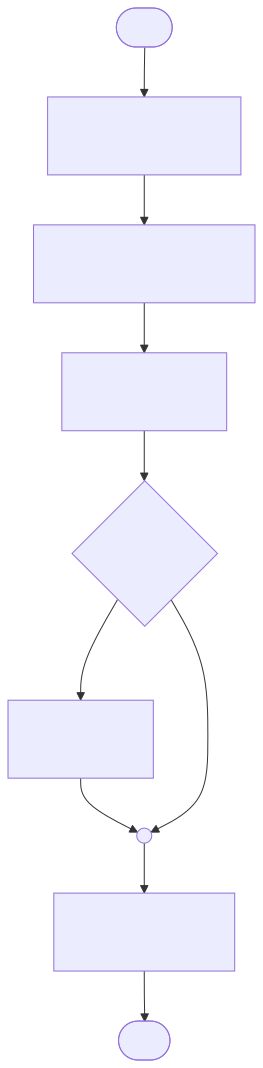

In [7]:
import base64
import requests
from IPython.display import SVG, display

def show_mermaid(code: str):
    graphbytes = code.encode("utf8")
    base64_string = base64.urlsafe_b64encode(graphbytes).decode("ascii")
    url = f"https://mermaid.ink/svg/{base64_string}"

    headers = {"User-Agent": "Mozilla/5.0"}
    resp = requests.get(url, headers=headers, timeout=15)

    if resp.status_code != 200:
        print(f"Failed ({resp.status_code}): {resp.text[:300]}")
        return None

    display(SVG(data=resp.content))
    
def agno_workflow_to_mermaid(workflow, direction: str = "TD") -> str:
    """Introspect an Agno Workflow and emit Mermaid flowchart syntax."""
    lines = [f"flowchart {direction}"]
    lines.append('    start(["start"])')
    counter = 0

    def executor_label(step) -> str:
        if step.agent is not None:
            return f"{step.name}<br/><i>agent: {step.agent.name}</i>"
        if step.team is not None:
            return f"{step.name}<br/><i>team</i>"
        if step.workflow is not None:
            return f"{step.name}<br/><i>nested workflow</i>"
        if step.executor is not None:
            fn_name = getattr(step.executor, "__name__", "function")
            return f"{step.name}<br/><i>fn: {fn_name}</i>"
        return step.name

    def walk(steps, prev_id, counter):
        for step in steps:
            counter += 1
            if isinstance(step, Condition):
                cond_id = f"cond{counter}"
                label = step.name or "condition"
                lines.append(f'    {cond_id}{{"{label}"}}')
                lines.append(f"    {prev_id} --> {cond_id}")

                # True branch
                true_prev = cond_id
                for sub in step.steps:
                    counter += 1
                    node_id = f"n{counter}"
                    lines.append(f'    {node_id}["{executor_label(sub)}"]')
                    lines.append(f"    {true_prev} -->|True| {node_id}")
                    true_prev = node_id

                # False branch: either else_steps, or a direct skip-ahead
                counter += 1
                merge_id = f"merge{counter}"
                lines.append(f'    {merge_id}(( ))')
                lines.append(f"    {true_prev} --> {merge_id}")

                if step.else_steps:
                    false_prev = cond_id
                    for sub in step.else_steps:
                        counter += 1
                        node_id = f"n{counter}"
                        lines.append(f'    {node_id}["{executor_label(sub)}"]')
                        lines.append(f"    {false_prev} -->|False| {node_id}")
                        false_prev = node_id
                    lines.append(f"    {false_prev} --> {merge_id}")
                else:
                    # No else_steps: False skips directly past the condition
                    lines.append(f"    {cond_id} -->|False| {merge_id}")

                prev_id = merge_id
            else:
                node_id = f"n{counter}"
                lines.append(f'    {node_id}["{executor_label(step)}"]')
                lines.append(f"    {prev_id} --> {node_id}")
                prev_id = node_id
        return prev_id, counter

    prev_id, counter = walk(workflow.steps, "start", counter)
    lines.append('    finish(["end"])')
    lines.append(f"    {prev_id} --> finish")

    return "\n".join(lines)

mermaid_code = agno_workflow_to_mermaid(translation_workflow, direction="TD")
print(mermaid_code)  # sanity check first
show_mermaid(mermaid_code)